### Bayesian MC dropout query strategies

Bayesian query strategies use Monte Carlo (MC) dropout to approximate uncertainty in deep learning models. This works by computing multiple forward passes through a neural network with the dropout layers activated. For this example we are going to use a subset of [_MNIST_](https://archive.ics.uci.edu/dataset/683/mnist+database+of+handwritten+digits) dataset, loaded from _sklearn_.

In [1]:
import numpy as np
import torch
from skorch import NeuralNetClassifier
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from activelearning.AL_cycle import plot_results, strategy_comparison
# from activelearning.queries.bayesian.mc_max_entropy import mc_max_entropy
from activelearning.queries.representative.kmeans_query import query_kmeans_foreach
from activelearning.queries.representative.random_query import query_random
from activelearning.utils.skorch_nnet import reshapedVGG

torch.manual_seed(123)
np.random.seed(123)

In [2]:
preprocess = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.48235, 0.45882, 0.40784], std=[0.229, 0.224, 0.225]),
    ]
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# device = torch.device("cpu")

In this case we are going to run the images though a [VGG16](https://pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html) neural network, as this architecture includes dropout layers. It already includes a feature extraction part, so we can pass images directly to the network.

In [3]:
# mnist_data = datasets.MNIST("./data", download=True, transform=preprocess)
# dataloader = DataLoader(mnist_data, shuffle=True, batch_size=1500)
# X, y = next(iter(dataloader))
#
# # read training data (subset of 1500 images from mnist)
# X_train, X_test, y_train, y_test = X[:1000], X[1000:1500], y[:1000], y[1000:1500]
# X_train = X_train.reshape(1000, -1)
# X_test = X_test.reshape(500, -1)
#
# # assemble initial data
# n_initial = 100
# initial_idx = np.random.choice(range(len(X_train)), size=n_initial, replace=False)
# X_initial = X_train[initial_idx]
# y_initial = y_train[initial_idx]
#
#
# # generate the pool
# # remove the initial data from the training dataset
# X_pool = np.delete(X_train, initial_idx, axis=0)
# y_pool = np.delete(y_train, initial_idx, axis=0)

In [4]:
import sys
import os
import numpy as np
import torch

from embeddings.embedding import MaskedReconstruction, MultimodalMAE

PROJECT_ROOT = os.path.abspath("../..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from al_data_process.data_preprocess import create_windowed_ts, map_class_label_to_idx
from al_data_process.dataset import stratified_sampling_train_val

window_length = 0.4
overlap = 0.25

invalid_classes = [14]
Xt_acc, Xt_gyr, Xt_mag, Xt_mic, y_org_label = create_windowed_ts(data_path="../../tool-tracking-data/",
                                                                     tool="electric_screwdriver",
                                                                     invalid_classes=invalid_classes,
                                                                     window_length = window_length,
                                                                     overlap = overlap)

all_classes, counts = np.unique(y_org_label, return_counts=True)
# print(len(y_org_label))
# print(all_classes, counts)

Xt_acc = Xt_acc[:, :, 1:].astype(np.float32)
Xt_gyr = Xt_gyr[:, :, 1:].astype(np.float32)
Xt_mag = Xt_mag[:, :, 1:].astype(np.float32)
Xt_mic = Xt_mic[:, :, 1:].astype(np.float32)

y = map_class_label_to_idx(y_org_label)

train_set, test_set = stratified_sampling_train_val(torch.from_numpy(Xt_acc),
                                                  torch.from_numpy(Xt_gyr),
                                                  torch.from_numpy(Xt_mag),
                                                  torch.from_numpy(Xt_mic),
                                                  torch.tensor(y))


X_pool = np.empty(len(train_set), dtype=object)
y_pool = np.empty(len(train_set))
for i in range(len(train_set)):
    X_pool[i] = train_set[i][0]
    y_pool[i] = train_set[i][1]


X_test = np.empty(len(test_set), dtype=object)
y_test = np.empty(len(test_set))
for i in range(len(test_set)):
    X_test[i] = test_set[i][0]
    y_test[i] = test_set[i][1]


model = MultimodalMAE().to(device)
recon = MaskedReconstruction().to(device)

checkpoint = torch.load("../embeddings/multimodal_mae.pth", map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
recon.load_state_dict(checkpoint['recon_state_dict'])

model.eval()
recon.eval()

print("Models loaded and ready for inference.")

@torch.no_grad()
def extract_embedding(acc, gyr, mag, mic):
    model.eval()
    acc, gyr, mag, mic = (
        acc.to(device),
        gyr.to(device),
        mag.to(device),
        mic.to(device).squeeze()
    )
    z, _ = model(acc, gyr, mag, mic)
    return z.cpu()


embeddings = []
for acc, gyr, mag, mic in X_pool:
    z = extract_embedding(acc, gyr, mag, mic)
    embeddings.append(z)

X_pool_embeddings = np.array(embeddings)

n_query = 100
selected_idx = np.random.choice(len(X_pool), size=n_query, replace=False)

X_initial = X_pool[selected_idx]
y_initial = y_pool[selected_idx]
X_initial_emb = X_pool_embeddings[selected_idx]

X_pool = np.delete(X_pool, selected_idx, axis=0)
y_pool = np.delete(y_pool, selected_idx, axis=0)
X_pool_embeddings = np.delete(X_pool_embeddings, selected_idx, axis=0)

[INFO] Preparing data from:
  ../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  ../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  ../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  ../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716


[INFO] Read data:   0%|          | 0/16 [00:00<?, ?it/s]

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-03-102.291.csv) and from the timestamps differ by 0.001Hz



[INFO] Read data:  12%|█▎        | 2/16 [00:00<00:01,  7.32it/s, file=MIC-03-8000.csv]

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-01-155.087.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-03-102.291.csv) and from the timestamps differ by 0.001Hz



...

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-02-102.291.csv) and from the timestamps differ by 0.001Hz



[INFO] Read annotation: 100%|██████████| 16/16 [00:01<00:00, 16.66it/s, file=data-02.annotation]

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-01-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-02-154.679.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-01-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-04-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-02-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (../../tool-tracking-data/electric_screwdriver/

[INFO] Read annotation: 100%|██████████| 16/16 [00:01<00:00, 11.06it/s, file=data-02.annotation]


[INFO] Finished with 4 measurement(s).
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
Segment: 100%|██████████| 19380/19380 [00:00<00:00, 111631.53it/s]
[2 3 4 5 6 7 8] [ 546  234  199   89   50   59 3606]
count_1_14: 3, count_invalid_classes: 8, count_maj_vote: 46, count_diff_label: 5
Models loaded and ready for inference.


We evaluate the performance of the VGG classifier that we are going to use on the complete training set. This will serve as reference metric for the active learning query strategies, as we want to reach the same accuracy but with less labeled data.

In [5]:
num_lstm_layers = 1
hidden_size = 32
dropout_p = 0.3
num_classes = 7

In [6]:

# BATCH_SIZE = 16
# LR = 2e-3
num_lstm_layers = 1
hidden_size = 32
dropout_p = 0.3
num_classes = 7

from model.lstm_classif import LSTM_CLASSIF
from sklearn.metrics import f1_score

#
# def compute_class_weights(class_counts, beta=0.999):
#     class_counts = class_counts.float()
#
#     # avoid division by zero
#     class_counts = torch.clamp(class_counts, min=1)
#
#     effective_num = 1.0 - torch.pow(beta, class_counts)
#     weights = (1.0 - beta) / effective_num
#
#     # normalize for stability
#     weights = weights / weights.mean()
#
#     return weights

def compute_class_weights_from_labels(y, beta=0.999):
    """
    Compute effective number class weights directly from labels.

    Args:
        y: array-like, shape (num_samples,)
           Class labels (int or float, discrete)
        beta: float, smoothing factor

    Returns:
        weights: np.array, shape (num_classes,)
    """
    classes, counts = np.unique(y, return_counts=True)
    classes = classes.astype(int)

    counts = counts.astype(np.float32)
    counts = np.maximum(counts, 1.0)

    effective_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / effective_num

    weights = weights / weights.mean()

    num_classes = int(np.max(classes)) + 1
    full_weights = np.zeros(num_classes, dtype=np.float32)
    full_weights[classes] = weights

    return full_weights




# class_counts = torch.bincount(y_pool.long(), minlength=num_classes)
# class_weights = compute_class_weights(class_counts)

class_weights = compute_class_weights_from_labels(y_pool, beta=0.999)
class_weights_tensor = torch.from_numpy(class_weights).float()


def collate_fn(batch):
    # separate features and labels
    x_batch, y_batch = zip(*batch)  # x_batch = list of tuples, y_batch = list of labels

    # transpose modalities
    acc, gyr, mag, mic = zip(*x_batch)  # each is a tuple of tensors

    # stack tensors along batch dimension (dim=0)
    acc = torch.stack(acc, dim=0)  # shape: (batch, time, features)
    gyr = torch.stack(gyr, dim=0)
    mag = torch.stack(mag, dim=0)
    mic = torch.stack(mic, dim=0)

    # convert labels to tensor
    if isinstance(y_batch[0], torch.Tensor):
        y_batch = torch.stack(y_batch).long()  # works if labels are 0-dim tensors
    else:
        y_batch = torch.tensor(y_batch, dtype=torch.long)


    return (acc, gyr, mag, mic), y_batch




classifier = NeuralNetClassifier(
    LSTM_CLASSIF(input_size=3, hidden_size=hidden_size, num_layers=num_lstm_layers, num_classes=num_classes,
                             dropout_p=dropout_p),
    criterion=torch.nn.CrossEntropyLoss,
    criterion__weight=class_weights_tensor,
    lr=2e-3,
    batch_size=16,
    iterator_train__collate_fn=collate_fn,
    iterator_valid__collate_fn=collate_fn,
    optimizer=torch.optim.Adam,
    train_split=None,
    max_epochs=100,
    device=device,
)

classifier.fit(X_pool, y_pool)

goal_acc = classifier.score(X_test, y_test)

y_pred = classifier.predict(X_test)
# print(y_pred.shape)
goal_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Goal Accuracy: {goal_acc}")
print(f"Goal F1 Score: {goal_f1}")

  epoch    train_loss     dur
-------  ------------  ------
      1        1.4579  1.5839
      2        1.1584  1.5140
      3        0.9640  1.5175
      4        0.8885  1.5223
      5        0.7933  1.5238
      6        0.7266  1.5204
      7        0.6955  1.5246
      8        0.6606  1.5085
      9        0.6027  1.4897
     10        0.5902  1.4789
     11        0.5716  1.4781
     12        0.5456  1.4779
     13        0.4948  1.4776
     14        0.5166  1.5039
     15        0.5444  1.5065
     16        0.4633  1.5498
     17        0.4597  1.5031
     18        0.4418  1.5026
     19        0.4222  1.5251
     20        0.4546  1.5082
     21        0.4145  1.5263
     22        0.4056  1.5329
     23        0.4191  1.5229
     24        0.3936  1.5253
     25        0.3927  1.5352
     26        0.3482  1.5239
     27        0.3550  1.5317
     28        0.3730  1.5367
     29        0.3531  1.5072
     30        0.3466  1.4995
     31        0.3218  1.5083
     32   

To compare how different query strategies perform, we can use the *strategy_comparison* function and pass the strategies to be used. We can also pass more than one number of instances, to check whether a different batch size influences performance. *plot_results* can be used to immediatly plot the output from *strategy_comparison*, or a custom graph can be created from the scores data frame.

In [7]:


n_instances = [100]
goal_metric = "f1"
# goal_metric = "acc"

classifier = NeuralNetClassifier(
    LSTM_CLASSIF(input_size=3, hidden_size=hidden_size, num_layers=num_lstm_layers, num_classes=num_classes,
                             dropout_p=dropout_p),
    criterion=torch.nn.CrossEntropyLoss,
    # criterion__weight=class_weights_tensor,
    lr=2e-3,
    batch_size=16,
    iterator_train__collate_fn=collate_fn,
    iterator_valid__collate_fn=collate_fn,
    optimizer=torch.optim.Adam,
    train_split=None,
    max_epochs=100,
    device=device,
)

scores = strategy_comparison(
    X_train=X_initial_emb,
    y_train=y_initial,
    X_pool=X_pool_embeddings,
    y_pool=y_pool,
    X_test=X_test,
    y_test=y_test,
    X_pool_org=X_pool,
    X_train_org=X_initial,
    # classifier="nnet_bo",
    classifier=classifier,
    # query_strategies=[mc_bald, mc_max_entropy, mc_max_varratios, query_random, mc_max_meanstd],
    query_strategies=[query_kmeans_foreach],
    # query_strategies=[mc_max_entropy],
    # query_strategies=[mc_max_entropy, mc_bald],
    # n_instances=[32],
    n_instances=n_instances,
    # goal_acc=goal_acc,
    goal_metric=goal_metric, 
    goal_metric_val = goal_f1 if goal_metric == "f1" else goal_acc
    # max_epochs=15,
)

  epoch    train_loss     dur
-------  ------------  ------
      1        1.8663  0.0770
      2        1.4876  0.0781
      3        1.0517  0.0773
      4        0.9711  0.0769
      5        0.9425  0.0767
      6        0.8688  0.0764
      7        0.8343  0.0765
      8        0.8548  0.0769
      9        0.7819  0.0777
     10        0.7629  0.0817
     11        0.7271  0.0779
     12        0.6868  0.0763
     13        0.6743  0.0765
     14        0.6523  0.0791
     15        0.6414  0.0791
     16        0.5941  0.0778
     17        0.5871  0.0767
     18        0.5777  0.0769
     19        0.5457  0.0769
     20        0.5236  0.0767
     21        0.4749  0.0765
     22        0.5149  0.0766
     23        0.4897  0.0766
     24        0.4759  0.0664
     25        0.5235  0.0627
     26        0.4461  0.0762
     27        0.4172  0.0762
     28        0.3894  0.0761
     29        0.3919  0.0760
     30        0.4017  0.0760
     31        0.4194  0.0803
     32   

[    kmeans accuracy  kmeans f1 score  kmeans inst
0          0.824513         0.394227          100
1          0.789694         0.343372          200
2          0.820334         0.321416          300
3          0.830084         0.378104          400
4          0.805014         0.349958          500
5          0.844011         0.404769          600
6          0.845404         0.410293          700
7          0.824513         0.370457          800
8          0.856546         0.396297          900
9          0.844011         0.375245         1000
10         0.850975         0.392572         1100
11         0.866295         0.471036         1200
12         0.855153         0.410419         1300
13         0.888579         0.512350         1400
14         0.878830         0.445385         1500
15         0.889972         0.554147         1600
16         0.903900         0.628720         1700
17         0.853760         0.560766         1800
18         0.901114         0.614137         1900

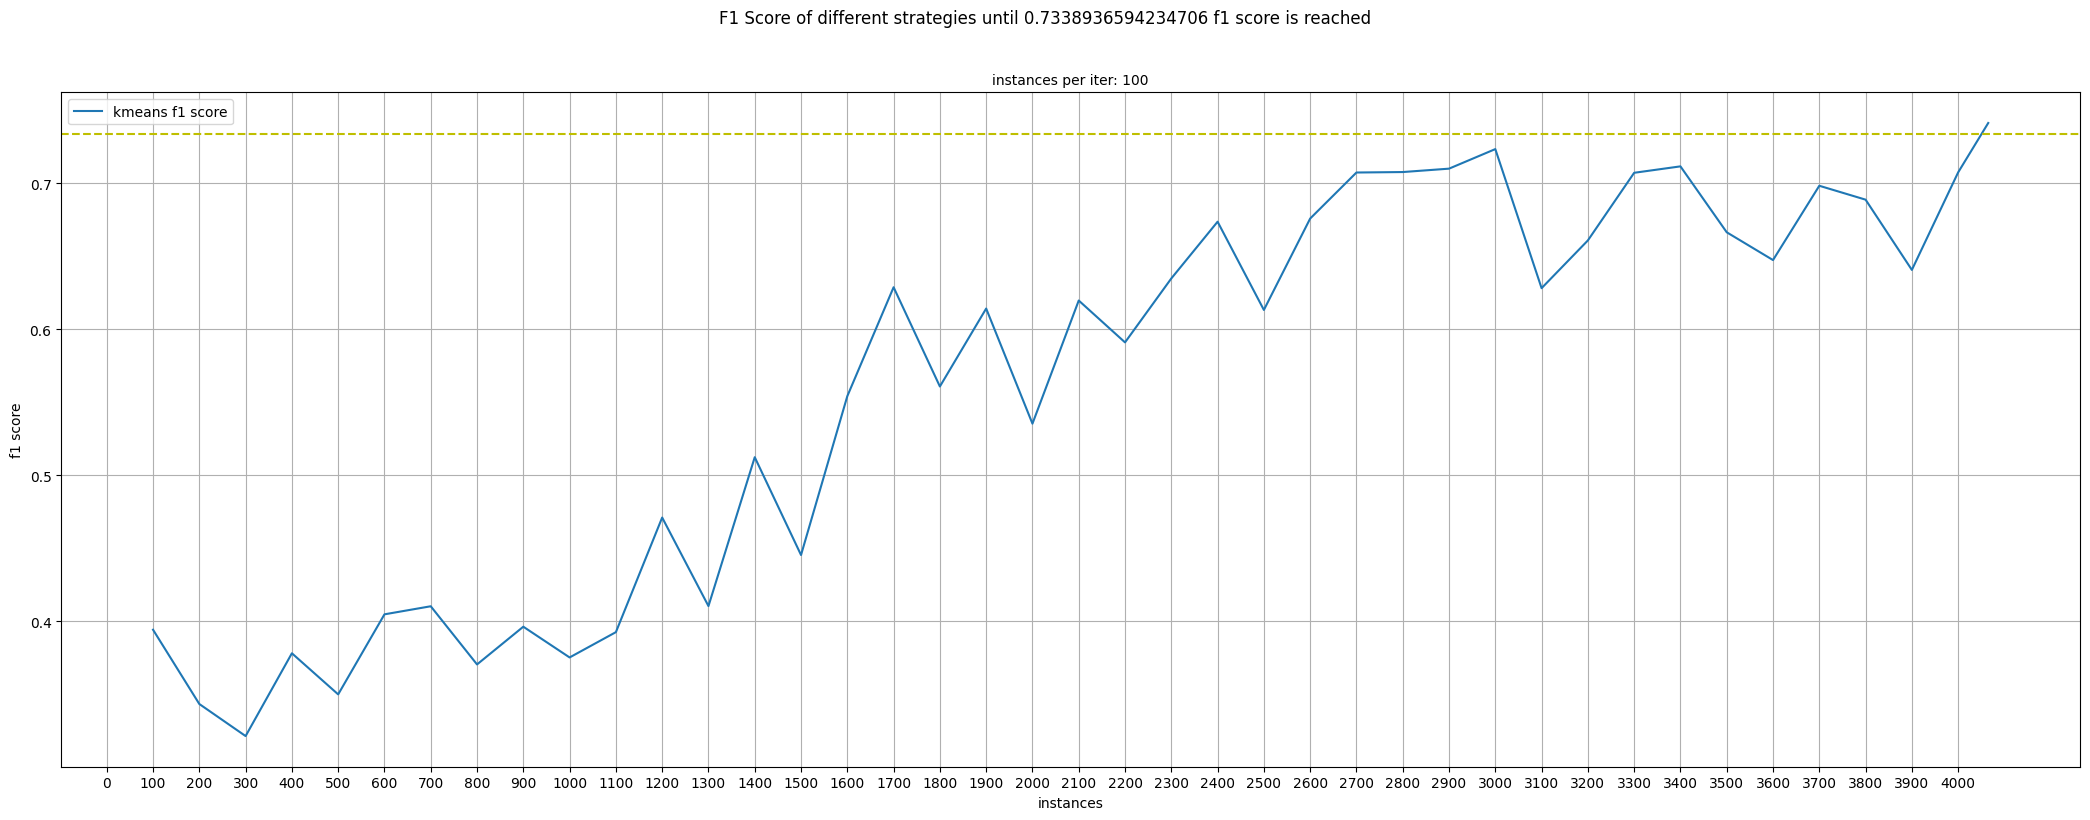

In [8]:
print(scores)


plot_results(
    scores,  # output data frame from strategy_comparison
    n_instances=n_instances,
    tot_samples=len(train_set),  # size of the original training set, for scale
    # goal_acc=goal_acc,
    figsize=(21, 8),
    goal_metric=goal_metric,
    goal_metric_val=goal_f1 if goal_metric == "f1" else goal_acc
)
